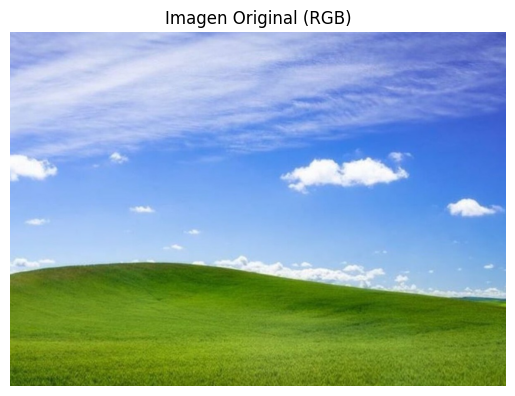

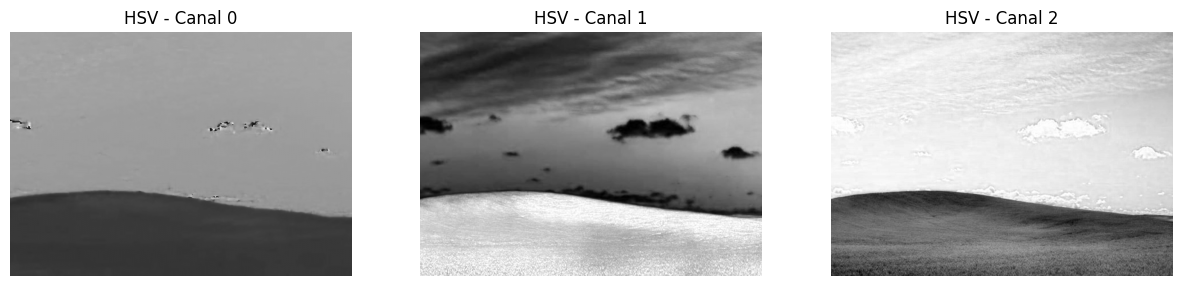

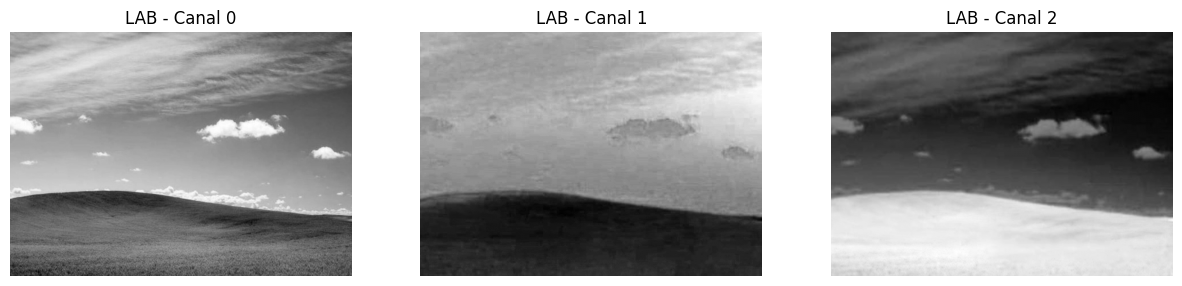

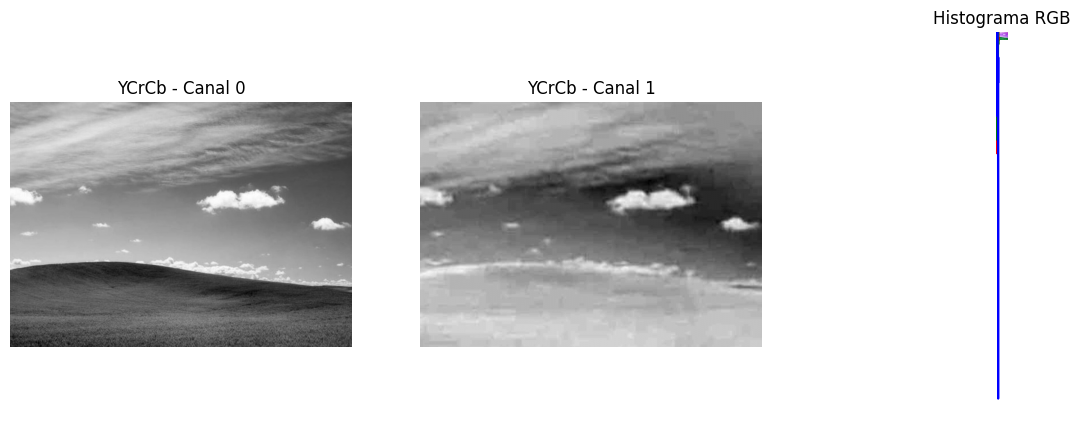

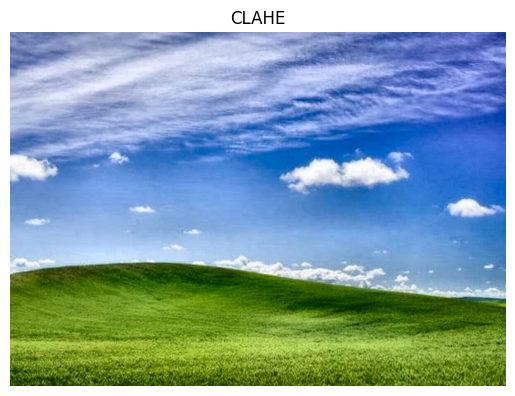

In [6]:
# INSTALACIÓN
# !pip install opencv-python scikit-image numpy matplotlib colormath

# IMPORTS
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import color
from sklearn.cluster import KMeans

# CARGAR IMAGEN
image_bgr = cv2.imread('image.jpg')
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title('Imagen Original (RGB)')
plt.axis('off')

# CONVERSIONES DE COLOR
hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
ycrcb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YCrCb)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

hsl = color.rgb2hsv(image_rgb)

# VISUALIZAR CANALES
def show_channels(img, title):
    channels = cv2.split(img)
    fig, axs = plt.subplots(1, len(channels), figsize=(15,5))
    for i, ch in enumerate(channels):
        axs[i].imshow(ch, cmap='gray')
        axs[i].set_title(f'{title} - Canal {i}')
        axs[i].axis('off')

show_channels(hsv, 'HSV')
show_channels(lab, 'LAB')
show_channels(ycrcb, 'YCrCb')

plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

# SEGMENTACIÓN POR COLOR (HSV)
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([130, 255, 255])

mask = cv2.inRange(hsv, lower_blue, upper_blue)

kernel = np.ones((5,5), np.uint8)
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

result = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_clean)

plt.imshow(mask_clean, cmap='gray')
plt.title('Máscara')
plt.axis('off')

plt.imshow(result)
plt.title('Segmentación Azul')
plt.axis('off')

# MANIPULACIÓN DE COLOR
# Aumentar saturación
hsv_mod = hsv.copy()
hsv_mod[:,:,1] = np.clip(hsv_mod[:,:,1]*1.5, 0, 255)
img_sat = cv2.cvtColor(hsv_mod, cv2.COLOR_HSV2RGB)

plt.imshow(img_sat)
plt.title('Mayor Saturación')
plt.axis('off')

# Rotar matiz
hsv_hue = hsv.copy()
hsv_hue[:,:,0] = (hsv_hue[:,:,0] + 30) % 180
img_hue = cv2.cvtColor(hsv_hue, cv2.COLOR_HSV2RGB)

plt.imshow(img_hue)
plt.title('Cambio de Matiz')
plt.axis('off')

# HISTOGRAMAS
colors = ('r','g','b')
for i, col in enumerate(colors):
    hist = cv2.calcHist([image_rgb],[i],None,[256],[0,256])
    plt.plot(hist, color=col)

plt.title('Histograma RGB')
plt.show()

# K-MEANS (COLORES DOMINANTES)
pixels = image_rgb.reshape((-1,3))

kmeans = KMeans(n_clusters=5)
kmeans.fit(pixels)
colors = kmeans.cluster_centers_.astype(int)

palette = np.zeros((100, 500, 3), dtype=np.uint8)
step = 500 // len(colors)

for i, color_val in enumerate(colors):
    palette[:, i*step:(i+1)*step] = color_val

plt.imshow(palette)
plt.title('Paleta de Colores')
plt.axis('off')

# COLOR GRADING SIMPLE
def warm_effect(img):
    result = img.copy().astype(np.float32)
    result[:,:,0] *= 1.1  # rojo
    result[:,:,2] *= 0.9  # azul
    return np.clip(result,0,255).astype(np.uint8)

warm = warm_effect(image_rgb)

plt.imshow(warm)
plt.title('Efecto Cálido')
plt.axis('off')

# CLAHE (ECUALIZACIÓN)
lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l_clahe = clahe.apply(l)

lab_clahe = cv2.merge((l_clahe,a,b))
img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

plt.imshow(img_clahe)
plt.title('CLAHE')
plt.axis('off')

# TRANSFERENCIA DE COLOR
def color_transfer(source, target):
    source_lab = cv2.cvtColor(source, cv2.COLOR_RGB2LAB).astype("float32")
    target_lab = cv2.cvtColor(target, cv2.COLOR_RGB2LAB).astype("float32")

    for i in range(3):
        source_mean, source_std = source_lab[:,:,i].mean(), source_lab[:,:,i].std()
        target_mean, target_std = target_lab[:,:,i].mean(), target_lab[:,:,i].std()

        target_lab[:,:,i] -= target_mean
        target_lab[:,:,i] *= (source_std / (target_std + 1e-5))
        target_lab[:,:,i] += source_mean

    result = cv2.cvtColor(target_lab.astype("uint8"), cv2.COLOR_LAB2RGB)
    return result
